# Data denoising for visual & qualitative analysis

In this tutorial, we will demonstrate how CellMapper can be used to "denoise" scRNA-seq data by sharing information among neighboring cells. Imputation for scRNA-seq data is firecly debated, and we do not advocate building quantiative models or evaluations on top of imputed data. However, imputation can be useful for visual analysis, to inspect gene expression values and how they change along (pseudo)-temporal covariates. 

The approach we take here is inspired by [MAGIC](https://magic.readthedocs.io/en/stable/) {cite:p}`van2018recovering`, however, it's much faster thanks to some linear algebra tricks. In this tutorial, we'll use [CellRank](https://cellrank.readthedocs.io/en/latest/){cite:p}`lange2022cellrank, weiler2024cellrank` to demonstrate expression trend plotting with imputed data. 

## Preliminaries

### Import packages & data

In [1]:
import matplotlib.pyplot as plt
import warnings
import scanpy as sc
import cellmapper

/Users/mlange/miniforge3/envs/cellmapper/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sc.set_figure_params(scanpy=True, frameon=False, fontsize=14)

We'll use a dataset of CD34+ human bone marrow cells. To learn more about this dataset, take a look at the original publication {cite:p}`setty2019characterization`. 

In [4]:
adata = sc.read("data/bone_marrow.h5ad", backup_url="https://figshare.com/ndownloader/files/56264870")
adata

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 76.1M/76.1M [00:07<00:00, 10.1MB/s]


AnnData object with n_obs × n_vars = 5780 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types'
    obsm: 'X_tsne', 'palantir_branch_probs'

This is raw data with some labels and `tsne` embedding coordinates. 

### Basic preprocessing

Let's go though some standard scanpy preprocessing. 

In [5]:
sc.pp.filter_genes(adata, min_cells=10)

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

sc.pp.highly_variable_genes(adata)
sc.pp.pca(adata)

sc.pp.neighbors(adata)

adata

AnnData object with n_obs × n_vars = 5780 × 12978
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_tsne', 'palantir_branch_probs', 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

### Basic visualization

Let's take a look at this in a t-SNE embedding, visualizing cell type labels and a pre-computed [Palantir](https://palantir.readthedocs.io/en/latest/){cite:p}`setty2019characterization` pseudotime. 

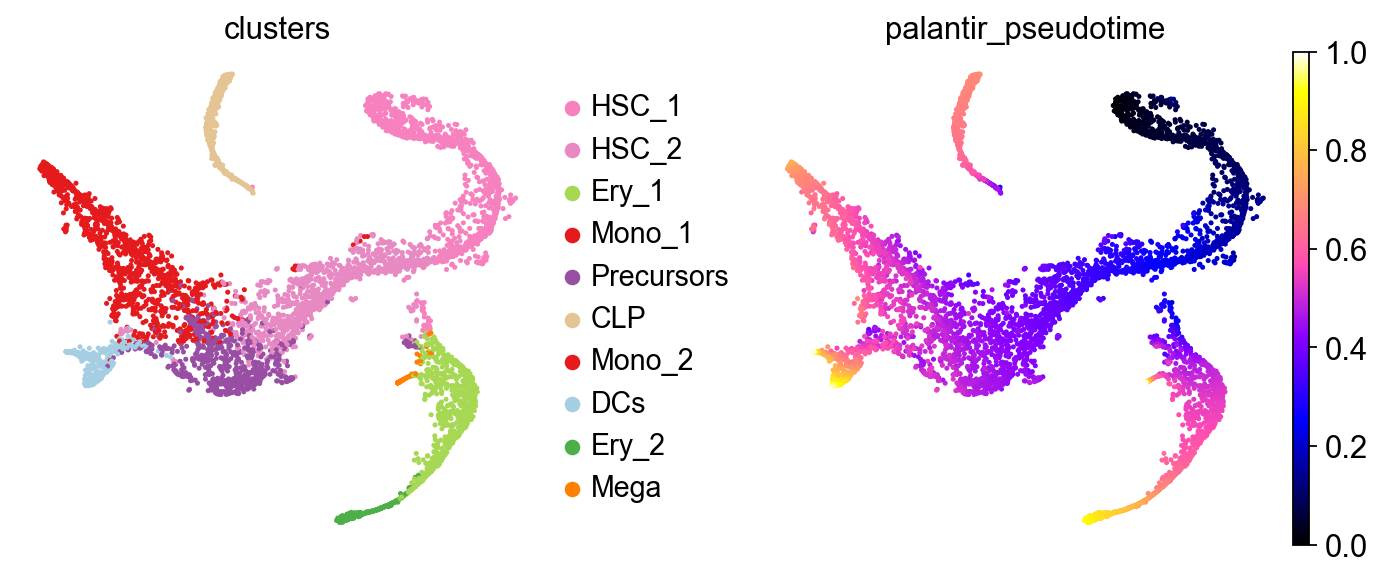

In [6]:
sc.pl.embedding(adata, color=["clusters", "palantir_pseudotime"], basis="tsne", wspace=0.3, cmap="gnuplot2")

## Denoising with CellMapper

Denoising in CellMapper comes down to computing a k-NN graph in self-mapping mode and matrix-multiplying the gene expression matrix with the normalized k-NN adjacencies. The degree of smoothing can be controlled with the `t` parameter, which controls how often we multiply the expression matric with the normalized graph adjacencies. For large `t`, we implement a spectral appraoch which is much faster than the native iterative approach. Let's start by initializing CellMapper in self-mapping mode by only providing a single AnnData object. 

In [7]:
smap = cellmapper.CellMapper(adata)
smap

INFO     Initialized CellMapper for self-mapping with 5780 cells.                                                  


CellMapper(self-mapping, data=AnnData(n_obs=5,780, n_vars=12,978), 

Compute a k-NN graph and mapping matrix in PCA space. 

In [8]:
smap.compute_neighbors(use_rep="X_pca")
smap.compute_mapping_matrix()

INFO     Self-mapping mode detected. Computing only yx neighbors for efficiency (all neighbor matrices will contain
         the same information).                                                                                    
INFO     Using sklearn to compute 30 neighbors.                                                                    
INFO     Computing mapping matrix using method 'umap'.                                                             


Great, now let's do the actual smoothing operation by multiplying the expression data with the mapping matrix, which corresponds to normalized graph adjacencies. 

In [9]:
smap.map_layers("X", t=3)
adata.layers["smap_t3"] = smap.query_imputed.X

INFO     Mapping layer for key 'X' with t=3 steps using iterative method                                           
INFO     Imputed expression matrix with shape (5780, 12978) converted to AnnData object.                           
         Observation metadata from query and feature metadata from reference were linked (not copied).             
INFO     Expression for layer 'X' mapped and stored in query_imputed.X.                                            


Let's visualize original and imputed expression values

layer=None


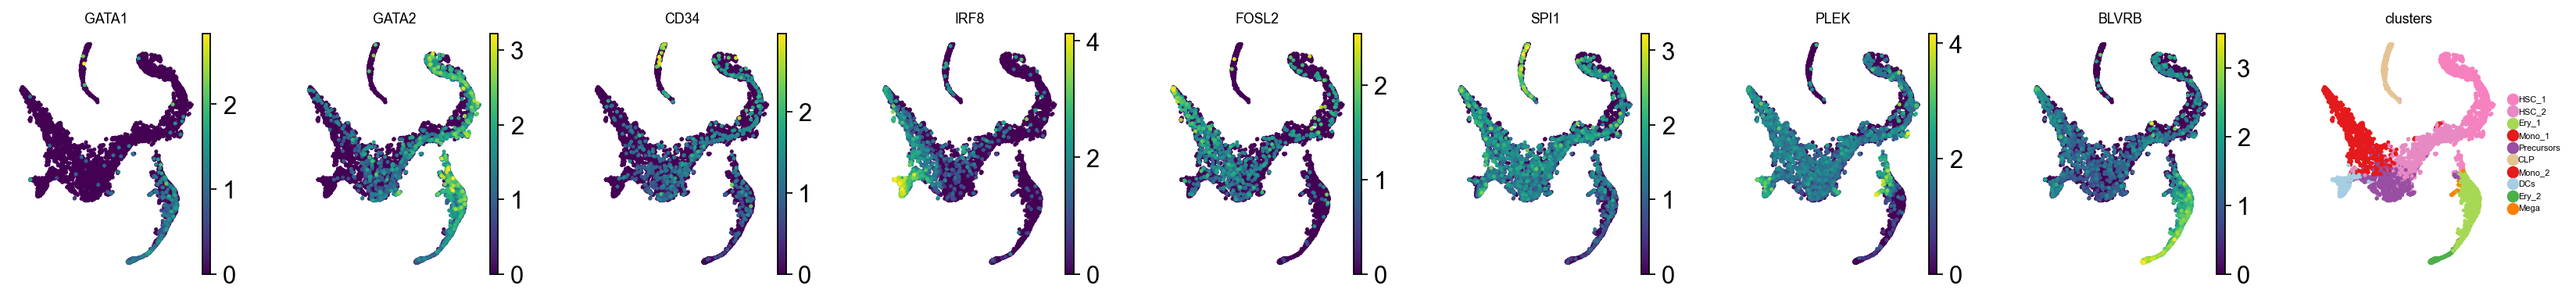

layer=smap_t3


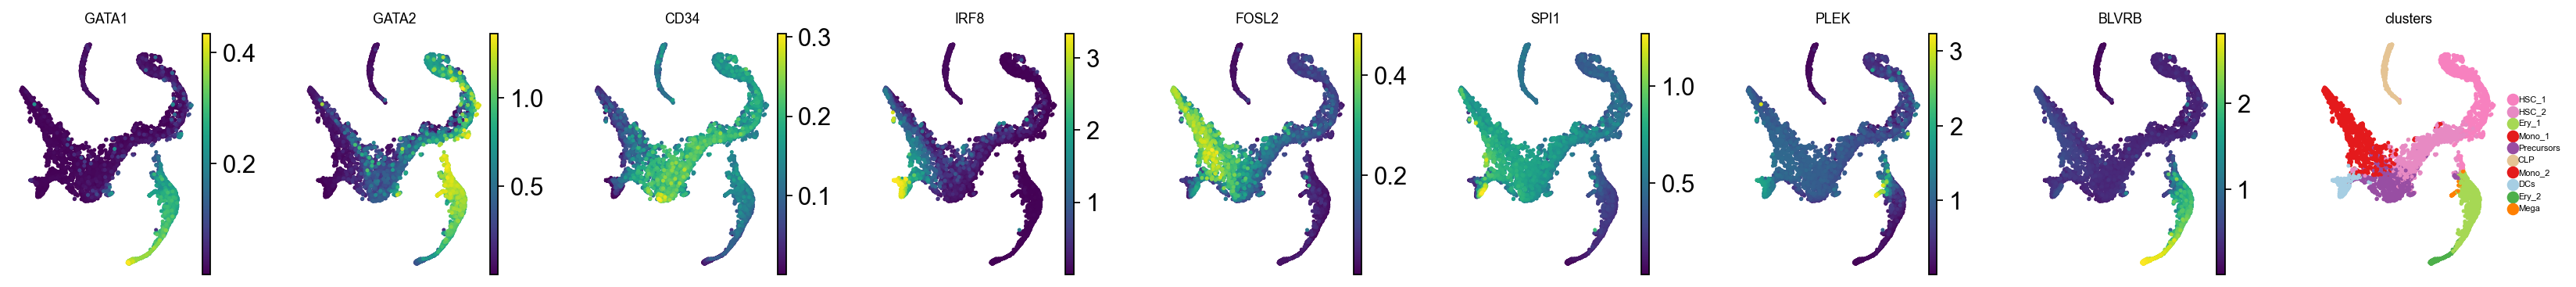

In [23]:
genes = ["GATA1", "GATA2", "CD34", "IRF8", "FOSL2", "SPI1", "PLEK", "BLVRB"]

with plt.rc_context({"figure.figsize": (2, 2.5), "legend.fontsize": 5, "axes.titlesize": 8}):
    for layer in [None, "smap_t3"]:
        print(f"layer={layer}")
        sc.pl.embedding(adata, basis="tsne", color=genes + ["clusters"], layer=layer, ncols=9)

For larger t values (corresponding to more smoothing), we recommend using the spectral appraoch, which is much faster, as we demonstrate below. 

In [11]:
%%time

smap.map_layers("X", t=10, method="iterative")

INFO     Mapping layer for key 'X' with t=10 steps using iterative method                                          
INFO     Imputed expression matrix with shape (5780, 12978) converted to AnnData object.                           
         Observation metadata from query and feature metadata from reference were linked (not copied).             
INFO     Expression for layer 'X' mapped and stored in query_imputed.X.                                            
CPU times: user 32.7 s, sys: 1.39 s, total: 34.1 s
Wall time: 34.3 s


In [12]:
%%time

smap.map_layers("X", t=10, method="spectral")

INFO     Mapping layer for key 'X' with t=10 steps using spectral method                                           
INFO     Computing symmetric eigendecomposition with 50 components for matrix powers                               
INFO     Imputed expression matrix with shape (5780, 12978) converted to AnnData object.                           
         Observation metadata from query and feature metadata from reference were linked (not copied).             
INFO     Expression for layer 'X' mapped and stored in query_imputed.X.                                            
CPU times: user 169 ms, sys: 34.4 ms, total: 203 ms
Wall time: 175 ms


We obtain a good two orders of magnitude speedup with the spectral approach. This becomes crucial for large t or large datasets. 

## Visualizing imputed expression trends with CellRank

One common application of data denoising is visualizing gene exression trends in pseudotime. Denoising isn't strictly necessary here - an alternative approach is using an NB noise model in the Generalized Additive Model (GAM), but that's computationally more expensive. Thus, many tools like CellRank work better with simple Gaussian noise models on imputed data. Again, keep in mind that we're only using the imputed data for visualization and not to compute other CellRank properties, like terminal states and fate probabilities. 

The workflow will be:

1. Set up a CellRank `PseudotimeKernel` to infer cellular dynamics based on the `PalantirPseudotime`
2. Using CellRank's `GPCCA` estimator, compute terminal states and fate probabilities towards them.
3. Using fate probabilities, Cellmapper-smoothed expression values, and the `PalantirPseudotime`, visualize trajectory-specific expression trends. 

### Set up CellRank PseudotimeKernel

To get started, let's set up a PseudotimeKernel in CellRank. You can learn more about this in the CellRank docs: https://cellrank.readthedocs.io/en/latest/index.html. 

In [13]:
from cellrank.kernels import PseudotimeKernel
from cellrank.estimators import GPCCA
import cellrank as cr

In [14]:
pk = PseudotimeKernel(adata, time_key="palantir_pseudotime")
pk.compute_transition_matrix()

pk

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████| 5780/5780 [00:00<00:00, 11617.52cell/s]


PseudotimeKernel[n=5780, dnorm=False, scheme='hard', frac_to_keep=0.3]

Let's take a look at the inferred dynamics with random walks. 

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:09<00:00, 10.26sim/s]


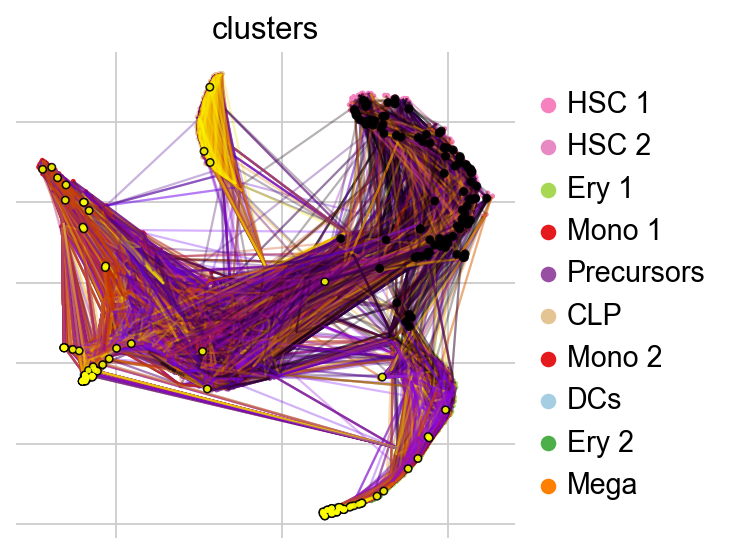

In [15]:
pk.plot_random_walks(
    n_sims=100,
    start_ixs={"clusters": "HSC_1"},
    basis="tsne",
    color="clusters",
    legend_loc="right",
    seed=1,
)

When we initialize random walks in the HSC_1 stem cell population, the finish mostly in terminal populations, like Monocytes or Erythrocytes. Next, we setup the CellRank estimator. 

### Compute terminal states and fate probabilities towards them

In [16]:
g = GPCCA(pk)
g

GPCCA[kernel=PseudotimeKernel[n=5780], initial_states=None, terminal_states=None]

Compute and visualize some macrostates

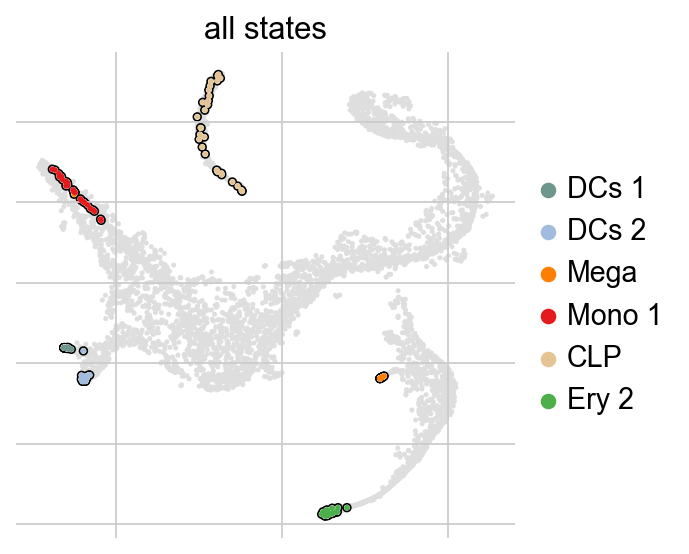

In [17]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)

    g.compute_macrostates(n_states=6, cluster_key="clusters")
    g.plot_macrostates(which="all", legend_loc="right")

Great, all of these represent terminal states, let's thus declare them terminal and compute fate probabilities towards them. 

In [18]:
g.set_terminal_states()
g.compute_fate_probabilities()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 63.04/s]


Let's take a look at these fate probabilities now. 

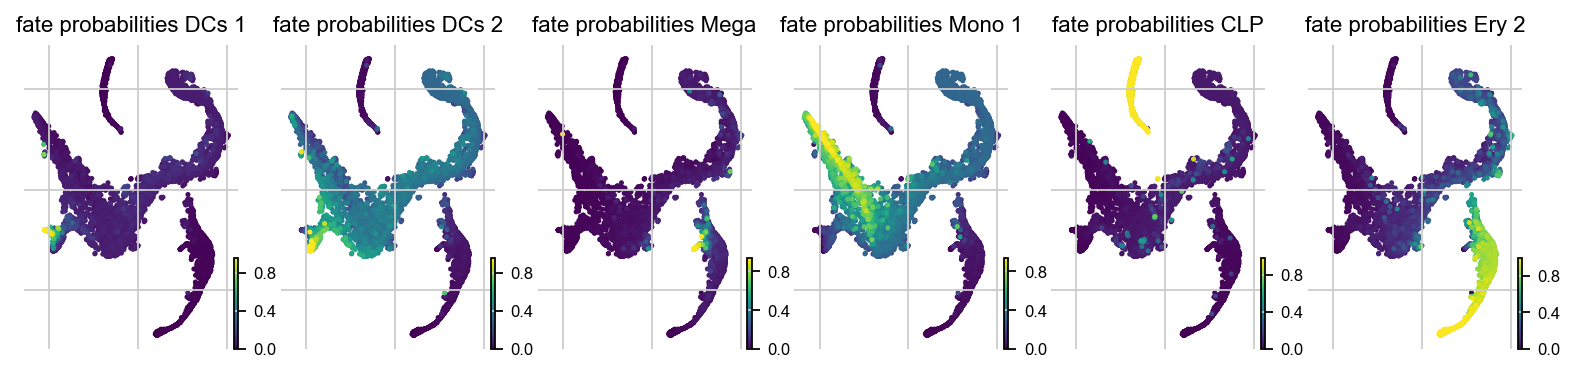

In [39]:
with plt.rc_context({"figure.figsize": (2, 2.5)}):
    g.plot_fate_probabilities(same_plot=False, fontsize=10)

We can summarize these fate probabilities in a cirular embedding. 

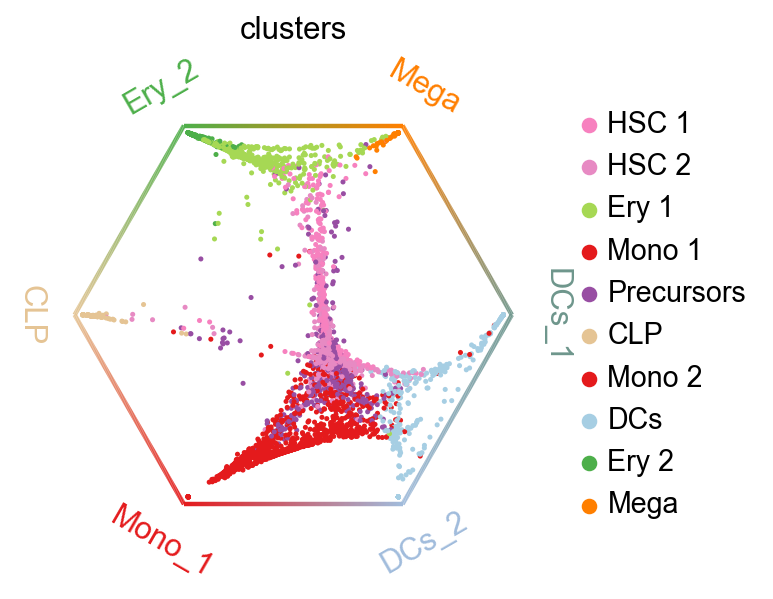

In [20]:
cr.pl.circular_projection(adata, keys="clusters", legend_loc="right")

### Visualize gene expression trends

Finally, we can put the pieces together. Below, we use Generative Additive Models (GAMs) to visualize CellMapper-smoothed expression values as a function of pseudotime, where we use CellRank fate probabilities to softly assign cells to different trajectories (each leading to one terminal state). 

In [21]:
model = cr.models.GAM(adata, n_knots=6)
model

<GAM[gene=None, lineage=None, model=GammaGAM(callbacks=['deviance', 'diffs'], fit_intercept=True, max_iter=2000, scale=None, terms=s(0), tol=0.0001, verbose=False)]>

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:03<00:00,  2.49gene/s]


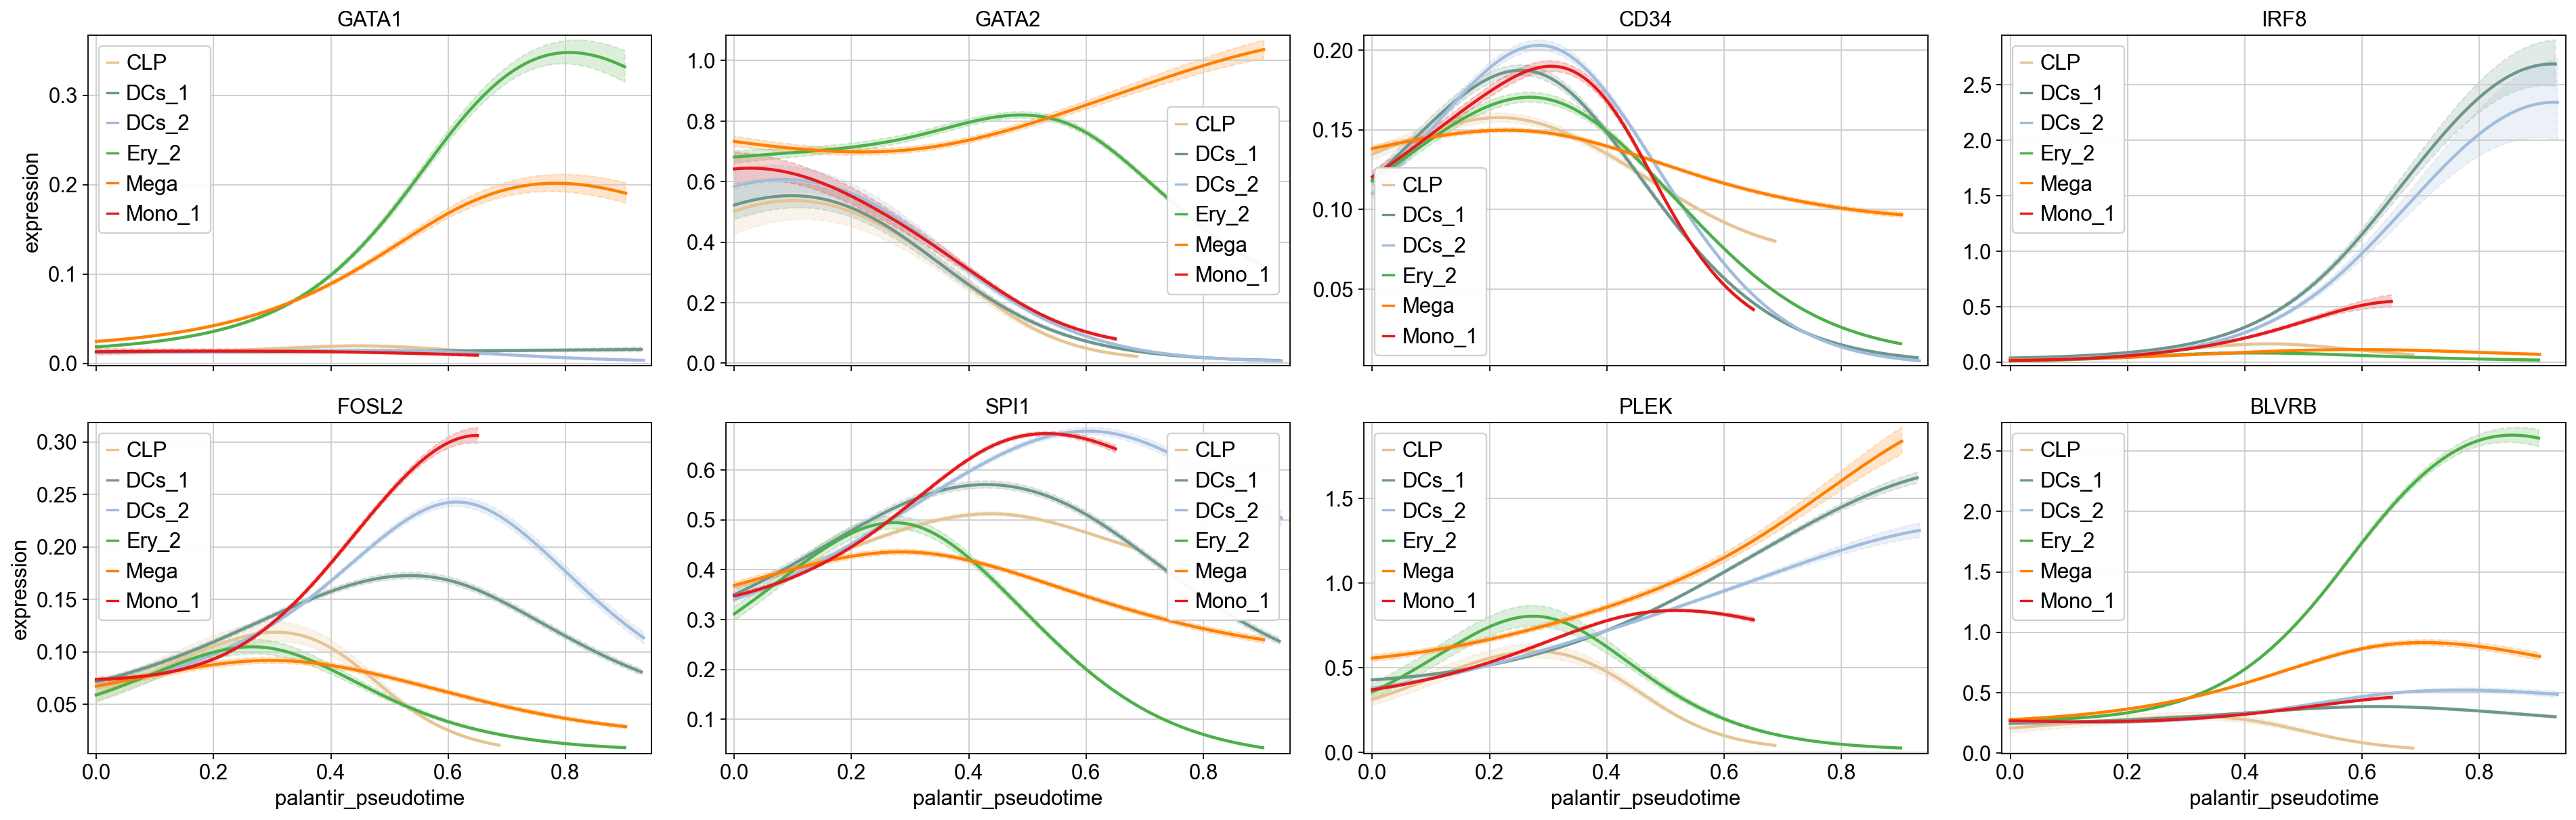

In [32]:
with plt.rc_context({"figure.figsize": (2, 3), "legend.fontsize": 14, "axes.titlesize": 14}):
    cr.pl.gene_trends(
        adata,
        model=model,
        data_key="smap_t3",
        genes=genes,
        same_plot=True,
        ncols=4,
        time_key="palantir_pseudotime",
        hide_cells=True,
        weight_threshold=(1e-3, 1e-3),
    )

We can see that we find genes with trajectory-specific trends, like GATA1, and others with more similar behavious across trajectories, like CD34. CellRank offers further analysis possibilities of these trends, like clustering, heatmap visualization, etc. Check out the corresponding CellRank tutorial to learn more: https://cellrank.readthedocs.io/en/latest/notebooks/tutorials/estimators/800_gene_trends.html#